In [ ]:
# Define dictionary of all datatypes and corresponding numbers
datatype_dict = {
    0: "CHIRPS_Rainfall",
    1: "eMODIS_NDVI_W_Africa",
    2: "eMODIS_NDVI_E_Africa",
    5: "eMODIS_NDVI_S_Africa",
    26: "NASA_IMERG_Late",
    28: "eMODIS_NDVI_Central_Asia",
    29: "ESI_4WEEK",
    31: "CHIRPS_GEFS_Forecast_Mean_Anom",
    32: "CHIRPS_GEFS_Forecast_Mean_Precip",
    33: "ESI_12WEEK",
    37: "USDA_SMAP_Soil_Moisture_Profile",
    38: "USDA_SMAP_Surface_Soil_Moisture",
    39: "USDA_SMAP_Surface_Soil_Moisture_Anom",
    40: "USDA_SMAP_Sub_Surface_Soil_Moisture",
    41: "USDA_SMAP_Sub_Surface_Soil_Moisture_Anom",
    90: "UCSB_CHIRP_Rainfall",
    91: "NASA_IMERG_Early",
    541: "NSIDC_SMAP_Sentinel_1Km",
    542: "NSIDC_SMAP_Sentinel_1Km_15_day",
    661: "LIS_ET",
    662: "LIS_Baseflow",
    663: "LIS_Runoff",
    664: "LIS_Soil_Moisture_0_10cm",
    665: "LIS_Soil_Moisture_10_40cm",
    666: "LIS_Soil_Moisture_40_100cm",
    667: "LIS_Soil_Moisture_100_200cm"
}


In [1]:
import pandas as pd
from climateservaccess import getClimateservData

# data_type: str, start_date: str, end_date: str, interval_type: int, operation_type: int, id: str, lat: float, lon: float
df = getClimateservData(542, '01/01/2015', '12/31/2022', 1, 5, '0', 0, 0)

Request submitted 
ID = 493d0160-e07a-46bb-8d06-192f5d1954b9
4.3%
25.6%
42.6%
63.9%
89.5%
100.0%
Data retrieved successfully.


In [3]:
df.head()

,data,polygon_Str_ToPass,uid,datatype,operationtype,intervaltype,derived_product
0,"{'year': 2015, 'month': 4, 'day': 1, 'date': '...","{""type"": ""FeatureCollection"", ""features"": [{""t...",493d0160-e07a-46bb-8d06-192f5d1954b9,542,5,1,False
1,"{'year': 2015, 'month': 4, 'day': 16, 'date': ...","{""type"": ""FeatureCollection"", ""features"": [{""t...",493d0160-e07a-46bb-8d06-192f5d1954b9,542,5,1,False
2,"{'year': 2015, 'month': 5, 'day': 1, 'date': '...","{""type"": ""FeatureCollection"", ""features"": [{""t...",493d0160-e07a-46bb-8d06-192f5d1954b9,542,5,1,False
3,"{'year': 2015, 'month': 5, 'day': 16, 'date': ...","{""type"": ""FeatureCollection"", ""features"": [{""t...",493d0160-e07a-46bb-8d06-192f5d1954b9,542,5,1,False
4,"{'year': 2015, 'month': 6, 'day': 1, 'date': '...","{""type"": ""FeatureCollection"", ""features"": [{""t...",493d0160-e07a-46bb-8d06-192f5d1954b9,542,5,1,False


In [4]:
temp_data = pd.DataFrame(df['datatype'].to_list())

def check_list(type_name): # check if the list is empty, has one value or multiple values
    type_list = df[type_name].unique().tolist()
    if len(type_list) == 0:
        return None
    elif len(type_list) == 1:
        return float(type_list[0])
    else:
        print(f"Multiple {type_name} found: {type_list}")
        return type_list
    
# find all unique values in the column and convert to list
datatype = check_list('datatype')
operationtype = check_list('operationtype')
intervaltype = check_list('intervaltype')

# create a dictionary with key as column name and values as list of unique values in the column
unique_values = {'datatype': datatype, 'operationtype': operationtype, 'intervaltype': intervaltype}
unique_values

{'datatype': 542.0, 'operationtype': 5.0, 'intervaltype': 1.0}

In [9]:
# Select data from df
NSIDC_SMAP_data = pd.DataFrame(df['data'].to_list())

# Find extreme negative values and replace with NaN
NSIDC_SMAP_data['raw_value'] = NSIDC_SMAP_data['raw_value'].apply(lambda x: float(x) if float(x) > -100 else None)

# Print stats on raw_value
print(f"NaN values in raw_value: {NSIDC_SMAP_data['raw_value'].isna().sum()}")
print(f"Min value in raw_value: {NSIDC_SMAP_data['raw_value'].min()}")
print(f"Max value in raw_value: {NSIDC_SMAP_data['raw_value'].max()}")

NSIDC_SMAP_data.head()

NaN values in raw_value: 0
Min value in raw_value: -9999.0
Max value in raw_value: 0.39042189717292786


,year,month,day,date,epochTime,value,raw_value,NaN,isodate
0,2015,4,1,04/01/2015,1427846400,{'avg': 0.07905693352222443},0.079057,37.49,04/01/2015
1,2015,4,16,04/16/2015,1429142400,{'avg': 0.16366586089134216},0.163666,62.17,04/01/2015
2,2015,5,1,05/01/2015,1430438400,{'avg': 0.10407165437936783},0.104072,16.56,05/01/2015
3,2015,5,16,05/16/2015,1431734400,{'avg': 0.10835647583007812},0.108356,9.23,05/01/2015
4,2015,6,1,06/01/2015,1433116800,{'avg': 0.11571052670478821},0.115711,11.21,06/01/2015


<Axes: title={'center': 'Raw Value vs Date'}, xlabel='date'>

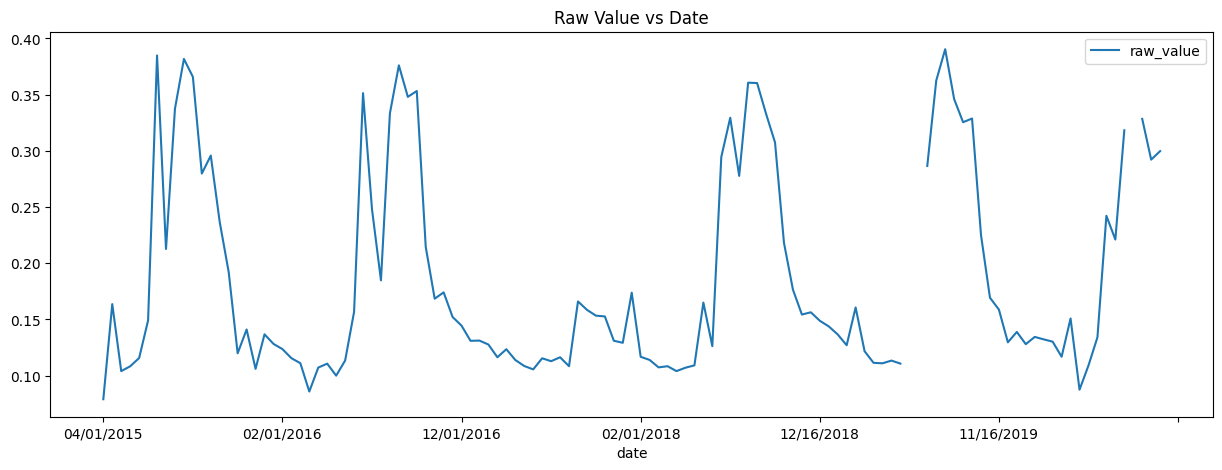

In [11]:
# Plot raw_value vs date
NSIDC_SMAP_data.plot(x='date', y='raw_value', figsize=(15,5), title='Raw Value vs Date')

In [12]:
import pandas as pd
from climateservaccess import getClimateservData

# data_type: str, start_date: str, end_date: str, interval_type: int, operation_type: int, id: str, lat: float, lon: float
df = getClimateservData('664', '01/01/2015', '12/31/2022', 1, 5, '0', 0, 0)

Request submitted 
ID = fca10283-d9eb-49db-8104-60712e01233d
3.7%
11.0%
14.7%
22.0%
33.0%
33.0%
36.7%
44.0%
51.3%
55.0%
62.3%
66.0%
77.0%
77.0%
88.0%
88.0%
88.0%
100.0%
Data retrieved successfully.


In [13]:
df.head()

,data,polygon_Str_ToPass,uid,datatype,operationtype,intervaltype,derived_product
0,"{'year': 2015, 'month': 1, 'day': 1, 'date': '...","{""type"": ""FeatureCollection"", ""features"": [{""t...",fca10283-d9eb-49db-8104-60712e01233d,664,5,1,False
1,"{'year': 2015, 'month': 1, 'day': 2, 'date': '...","{""type"": ""FeatureCollection"", ""features"": [{""t...",fca10283-d9eb-49db-8104-60712e01233d,664,5,1,False
2,"{'year': 2015, 'month': 1, 'day': 3, 'date': '...","{""type"": ""FeatureCollection"", ""features"": [{""t...",fca10283-d9eb-49db-8104-60712e01233d,664,5,1,False
3,"{'year': 2015, 'month': 1, 'day': 4, 'date': '...","{""type"": ""FeatureCollection"", ""features"": [{""t...",fca10283-d9eb-49db-8104-60712e01233d,664,5,1,False
4,"{'year': 2015, 'month': 1, 'day': 5, 'date': '...","{""type"": ""FeatureCollection"", ""features"": [{""t...",fca10283-d9eb-49db-8104-60712e01233d,664,5,1,False


In [14]:
# Select data from df
LIS_1_10_data = pd.DataFrame(df['data'].to_list())

# Find extreme negative values and replace with NaN
LIS_1_10_data['raw_value'] = LIS_1_10_data['raw_value'].apply(lambda x: float(x) if float(x) > -100 else None)

# Print stats on raw_value
print(f"NaN values in raw_value: {LIS_1_10_data['raw_value'].isna().sum()}")
print(f"Min value in raw_value: {LIS_1_10_data['raw_value'].min()}")
print(f"Max value in raw_value: {LIS_1_10_data['raw_value'].max()}")

LIS_1_10_data.head()

NaN values in raw_value: 0
Min value in raw_value: 0.07598423957824707
Max value in raw_value: 0.4052736163139343


,year,month,day,date,epochTime,value,raw_value,NaN,isodate
0,2015,1,1,01/01/2015,1420070400,{'avg': 0.10169069468975067},0.101691,7.28,01/01/2015
1,2015,1,2,01/02/2015,1420156800,{'avg': 0.10094679892063141},0.100947,7.28,01/01/2015
2,2015,1,3,01/03/2015,1420243200,{'avg': 0.10030357539653778},0.100304,7.28,01/01/2015
3,2015,1,4,01/04/2015,1420329600,{'avg': 0.09972528368234634},0.099725,7.28,01/01/2015
4,2015,1,5,01/05/2015,1420416000,{'avg': 0.09913448244333267},0.099134,7.28,01/01/2015


<Axes: title={'center': 'Raw Value vs Date'}, xlabel='date'>

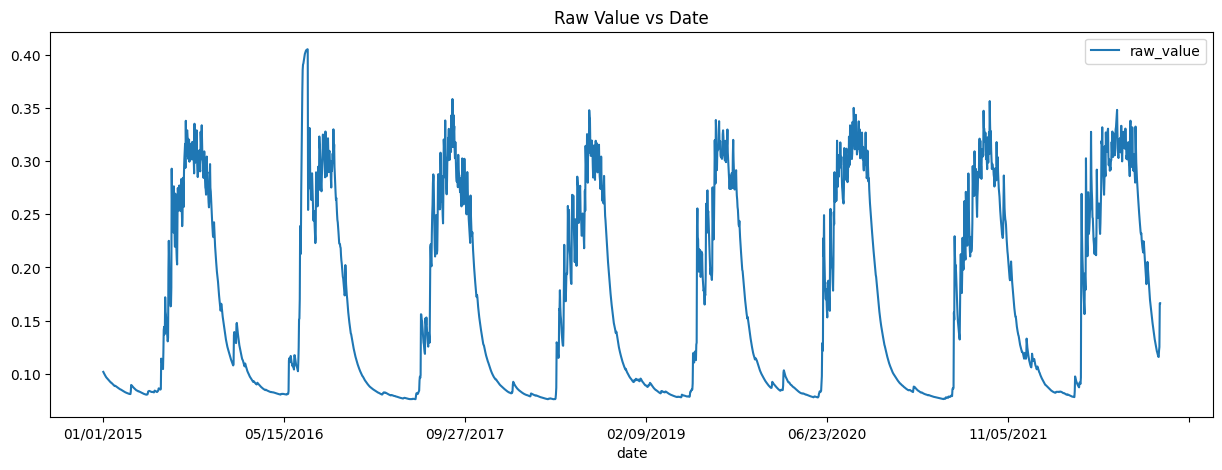

In [15]:
# Plot raw_value vs date
LIS_1_10_data.plot(x='date', y='raw_value', figsize=(15,5), title='Raw Value vs Date')